In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf


In [3]:
df = pd.read_csv('../../datasets/processed/axf_merged.csv')

In [4]:
model_1 = smf.ols(
    formula="""
    Q('% dry after 24h in humidity') ~
    Q('Impellor Speed (rpm)') +
    Q('Dispersed Flow Rate (mL/min)') +
    Q('Flow Rate Ratio')
    """,
    data=df
).fit()

print(model_1.summary())

                                   OLS Regression Results                                   
Dep. Variable:     Q('% dry after 24h in humidity')   R-squared:                       0.035
Model:                                          OLS   Adj. R-squared:                  0.030
Method:                               Least Squares   F-statistic:                     7.470
Date:                              Wed, 29 Apr 2026   Prob (F-statistic):           6.43e-05
Time:                                      16:56:48   Log-Likelihood:                -2983.2
No. Observations:                               619   AIC:                             5974.
Df Residuals:                                   615   BIC:                             5992.
Df Model:                                         3                                         
Covariance Type:                          nonrobust                                         
                                        coef    std err          t    

In [5]:
model_2 = smf.ols(
    formula="""
    Q('% dry after 24h in humidity') ~
    Q('Dispersed Flow Rate (mL/min)') +
    Q('Flow Rate Ratio')
    """,
    data=df
).fit()

print(model_2.summary())

                                   OLS Regression Results                                   
Dep. Variable:     Q('% dry after 24h in humidity')   R-squared:                       0.035
Model:                                          OLS   Adj. R-squared:                  0.032
Method:                               Least Squares   F-statistic:                     11.22
Date:                              Wed, 29 Apr 2026   Prob (F-statistic):           1.63e-05
Time:                                      16:56:48   Log-Likelihood:                -2983.2
No. Observations:                               619   AIC:                             5972.
Df Residuals:                                   616   BIC:                             5986.
Df Model:                                         2                                         
Covariance Type:                          nonrobust                                         
                                        coef    std err          t    

In [6]:
model_3 = smf.ols(
    formula="""
    Q('% dry after 24h in humidity') ~
    Q('Dispersed Flow Rate (mL/min)') +
    Q('Flow Rate Ratio') +
    Q('UV viscosity (cP)') +
    Q('Emulsion viscosity (cP)') +
    Q('Outer viscosity (cP)') +
    Q('Membrane Used (µm)') +
    Q('UV Power (J s-1)')
    """,
    data=df
).fit()

print(model_3.summary())

                                   OLS Regression Results                                   
Dep. Variable:     Q('% dry after 24h in humidity')   R-squared:                       0.146
Model:                                          OLS   Adj. R-squared:                  0.134
Method:                               Least Squares   F-statistic:                     12.80
Date:                              Wed, 29 Apr 2026   Prob (F-statistic):           3.15e-15
Time:                                      16:56:48   Log-Likelihood:                -2527.7
No. Observations:                               533   AIC:                             5071.
Df Residuals:                                   525   BIC:                             5106.
Df Model:                                         7                                         
Covariance Type:                          nonrobust                                         
                                        coef    std err          t    

In [7]:
model_4 = smf.ols(
    formula="""
    Q('% dry after 24h in humidity') ~
    Q('Dispersed Flow Rate (mL/min)') +
    Q('Flow Rate Ratio') +
    Q('UV viscosity (cP)') +
    Q('Emulsion viscosity (cP)') +
    Q('Outer viscosity (cP)') +
    Q('UV Power (J s-1)')
    """,
    data=df
).fit()

print(model_4.summary())

                                   OLS Regression Results                                   
Dep. Variable:     Q('% dry after 24h in humidity')   R-squared:                       0.145
Model:                                          OLS   Adj. R-squared:                  0.135
Method:                               Least Squares   F-statistic:                     14.81
Date:                              Wed, 29 Apr 2026   Prob (F-statistic):           1.13e-15
Time:                                      16:56:48   Log-Likelihood:                -2528.1
No. Observations:                               533   AIC:                             5070.
Df Residuals:                                   526   BIC:                             5100.
Df Model:                                         6                                         
Covariance Type:                          nonrobust                                         
                                        coef    std err          t    

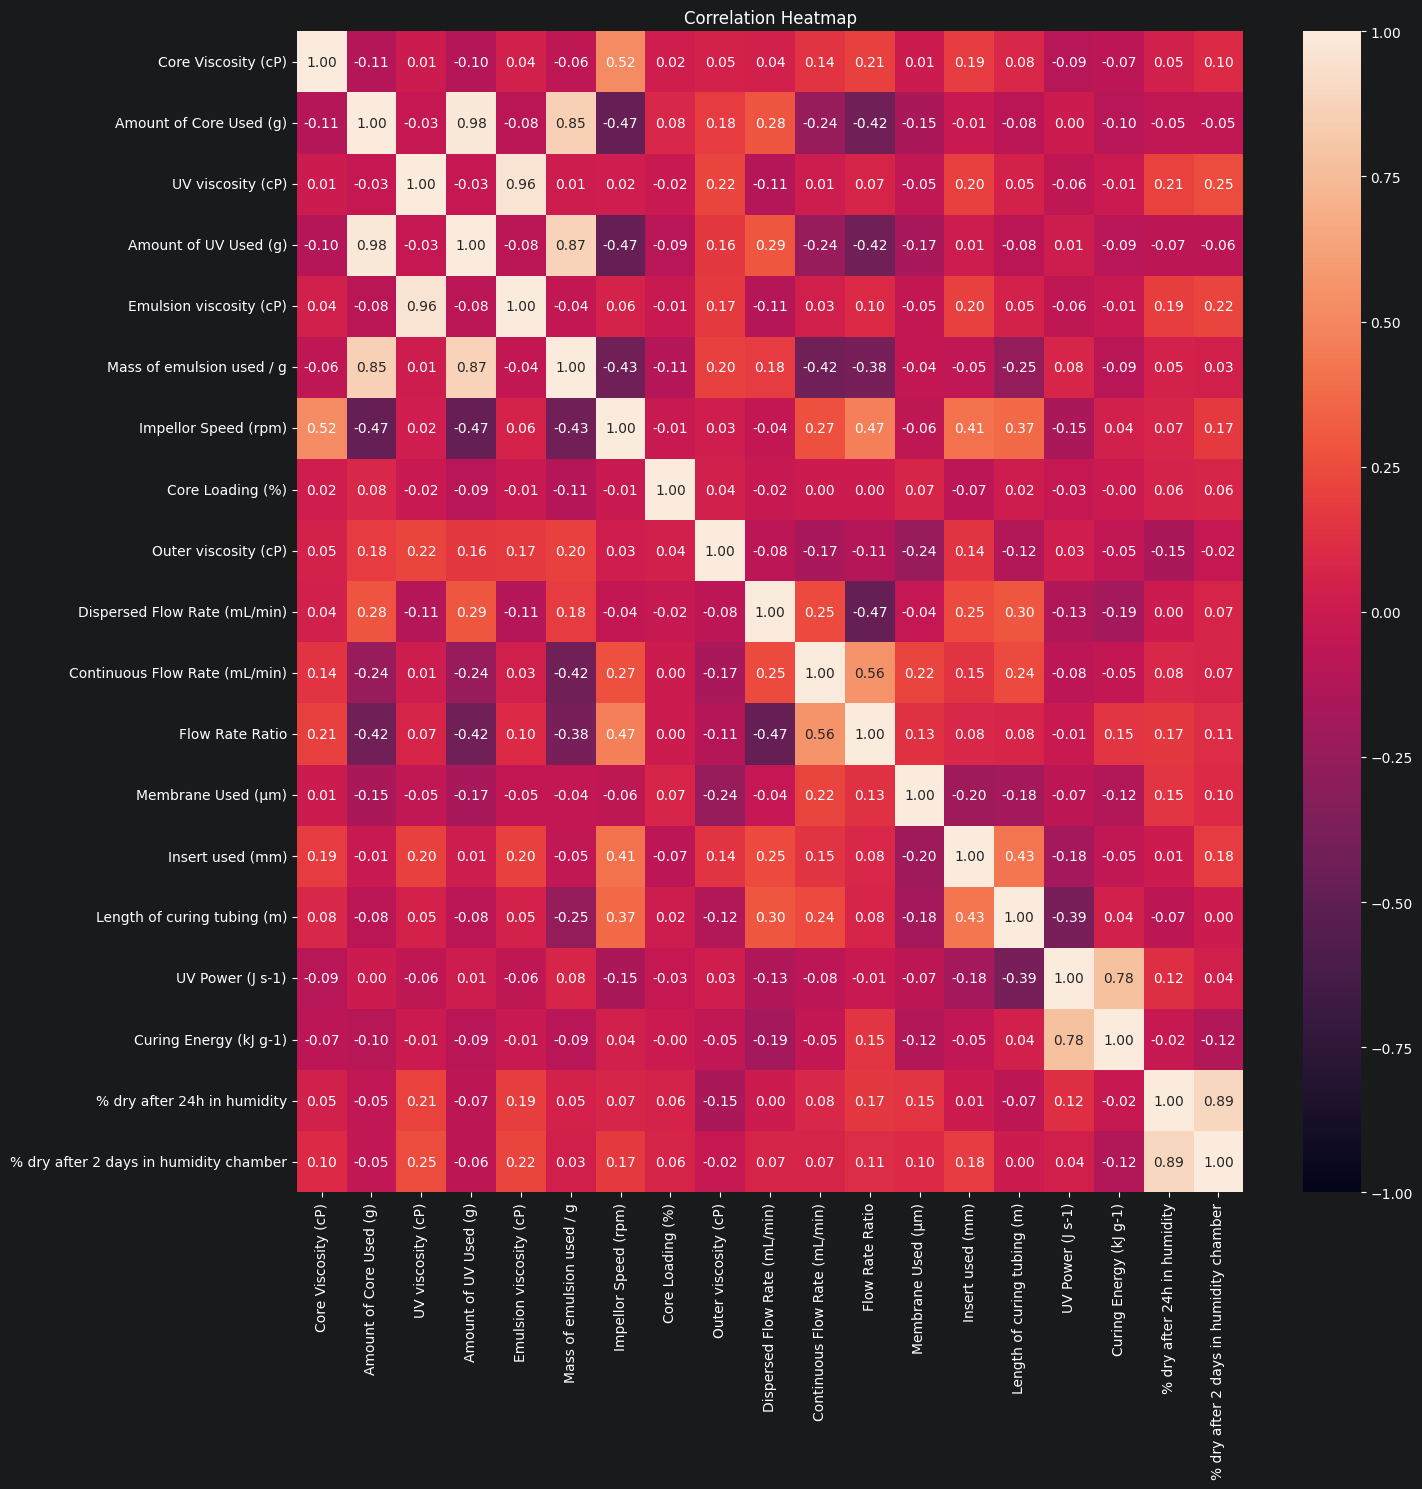

In [8]:
dfc =  df.select_dtypes(include='number').corr()
plt.figure(figsize=(15, 15))
sns.heatmap(dfc.astype(float), annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [9]:
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor

formula = """
    Q('% dry after 24h in humidity') ~
    Q('Dispersed Flow Rate (mL/min)') +
    Q('Flow Rate Ratio') +
    Q('UV viscosity (cP)') +
    Q('Emulsion viscosity (cP)') +
    Q('Outer viscosity (cP)') +
    Q('UV Power (J s-1)')
"""

# Tạo ma trận y, X từ đúng formula
y, X = dmatrices(formula, data=df, return_type='dataframe')

# X lúc này có cả cột Intercept, ta bỏ nó ra khi đọc kết quả VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                            Variable        VIF
0                          Intercept  83.340715
1  Q('Dispersed Flow Rate (mL/min)')   1.337886
2               Q('Flow Rate Ratio')   1.310272
3             Q('UV viscosity (cP)')  15.084555
4       Q('Emulsion viscosity (cP)')  14.525181
5          Q('Outer viscosity (cP)')   1.205857
6              Q('UV Power (J s-1)')   1.030861


In [10]:
model_5 = smf.ols(
    formula="""
    Q('% dry after 24h in humidity') ~
    Q('Dispersed Flow Rate (mL/min)') +
    Q('UV viscosity (cP)') +
    Q('Flow Rate Ratio') +
    Q('Outer viscosity (cP)') +
    Q('UV Power (J s-1)')
    """,
    data=df
).fit()

print(model_5.summary())

                                   OLS Regression Results                                   
Dep. Variable:     Q('% dry after 24h in humidity')   R-squared:                       0.113
Model:                                          OLS   Adj. R-squared:                  0.105
Method:                               Least Squares   F-statistic:                     14.22
Date:                              Wed, 29 Apr 2026   Prob (F-statistic):           4.10e-13
Time:                                      16:56:49   Log-Likelihood:                -2680.7
No. Observations:                               564   AIC:                             5373.
Df Residuals:                                   558   BIC:                             5399.
Df Model:                                         5                                         
Covariance Type:                          nonrobust                                         
                                        coef    std err          t    

In [11]:
model_6 = smf.ols(
    formula="""
    Q('% dry after 24h in humidity') ~
    Q('Dispersed Flow Rate (mL/min)') +
    Q('Flow Rate Ratio') +
    Q('UV Power (J s-1)')
    """,
    data=df
).fit()

print(model_6.summary())

                                   OLS Regression Results                                   
Dep. Variable:     Q('% dry after 24h in humidity')   R-squared:                       0.045
Model:                                          OLS   Adj. R-squared:                  0.040
Method:                               Least Squares   F-statistic:                     9.176
Date:                              Wed, 29 Apr 2026   Prob (F-statistic):           6.13e-06
Time:                                      16:56:49   Log-Likelihood:                -2802.0
No. Observations:                               584   AIC:                             5612.
Df Residuals:                                   580   BIC:                             5630.
Df Model:                                         3                                         
Covariance Type:                          nonrobust                                         
                                        coef    std err          t    

In [12]:
uv_c = pd.read_csv('../../datasets/processed/uv_cleaned.csv')
uv_b_c = pd.read_csv('../../datasets/processed/uv_batch_cleaned.csv')

In [13]:
df2 = pd.merge(df, uv_b_c, left_on='uv_batch_id', right_on='Batch Number ', how='left')

df2 = df2.drop(columns=['Batch Number ', 'Formulation', 'Viscosity @ RT RPM', 'Temp (°C) at visco measurement ', 'Cure ', 'QC operator initials', 'QC addition ', 'Pass/Fail'])

df2 = pd.merge(df2, uv_c, left_on='UV formulation', right_on='Sample', how='left')

df2 = df2.drop(columns=['Sample'])

df2[['ESBOA', 'Epoxy:GPTA 75:25', 'Miramer PU2560',
       'Photocryl DP408NT (40% DPGDA)', 'Miramer U360NT', 'Miramer U3195NT',
       'Miramer U3926NT', 'Miramer U3969NT', 'Miramer MU9800',
       'Miramer PU2100NT', 'Miramer SIU2400', 'Miramer SIP900',
       'Miramer SP1106', 'BR-5541M', 'BR-640D', 'BR-643', 'BR-990', 'BRC-843D',
       'CN9276', 'PEG200Da', 'PEG360MA', 'Miramer M142 (PHEA-2)',
       'Lauryl Acrylate', 'IDA', 'TPGDA', 'TMP(3EO)TA', 'TMPTA', 'HDDA',
       'SR833S', 'SR399', 'SR834', 'GPTA', 'SR295', 'IBOA', 'IPEMA',
       'Miramer M180 (Stearyl Acrylate)', 'Miramer M166 (NP(EO8)A)',
       'Miramer M2101 (BPA(EO)10DMA', 'Miramer M206 (HD(EO)nDA)',
       'Miramer M4004 (PE(EO)nTA)', 'Sarbio 5201 (DDDA)',
       'Miramer M222 (DPGDA)', 'Miramer 144 (PHEA-4)', 'Debonding Reading',
       'UVF339 (CAB in HDDA)', 'UVF540 (Diamond Solucote in HDDA)',
       'LU62406 (Diamond Receptive in HDDA)', 'LU62407(Diamond CAP in HDDA)',
       'LU62408 (G1159 in HDDA))', 'LU62405 (A81 in HDDA)',
       'Omnirad 819 (BAPO) -Type I', 'BDK - Type I', 'Omnirad MBF - Type II',
       'Omnipol BP - Polymeric Type II', 'Omnirad 1173 - Type I',
       'BP2702/2959 (80:20 blend) -Type II/I', 'TPO-L -Type I',
       'DETX - Type II', 'MBB - Type II', 'MBZ - Type II',
       'Omnirad 184 -Type I', 'JRcure1919', 'JRcure1607', 'Chiguard',
       'Tinuvin123', 'Tinuvin1130', 'Tetrabromomethane', 'Titanium Dioxide',
       'Agitan 760', 'Radwax 15/30', 'Radactive SF', 'Tego Wet 270',
       'Tego Glide 432', 'Tego wet 288', 'Foamtroll 110', 'Aerosil R816',
       'Aerosil E805', 'Aerosil E812', 'HS417-1', 'Gasil HP33C', 'Span80',
       'Synperonic 91/2.5 LQ', 'Agitan DF 6422', 'TEA', 'GC1100Y',
       'Agisyn 008', 'GC1000Z']] = df2[['ESBOA', 'Epoxy:GPTA 75:25', 'Miramer PU2560',
       'Photocryl DP408NT (40% DPGDA)', 'Miramer U360NT', 'Miramer U3195NT',
       'Miramer U3926NT', 'Miramer U3969NT', 'Miramer MU9800',
       'Miramer PU2100NT', 'Miramer SIU2400', 'Miramer SIP900',
       'Miramer SP1106', 'BR-5541M', 'BR-640D', 'BR-643', 'BR-990', 'BRC-843D',
       'CN9276', 'PEG200Da', 'PEG360MA', 'Miramer M142 (PHEA-2)',
       'Lauryl Acrylate', 'IDA', 'TPGDA', 'TMP(3EO)TA', 'TMPTA', 'HDDA',
       'SR833S', 'SR399', 'SR834', 'GPTA', 'SR295', 'IBOA', 'IPEMA',
       'Miramer M180 (Stearyl Acrylate)', 'Miramer M166 (NP(EO8)A)',
       'Miramer M2101 (BPA(EO)10DMA', 'Miramer M206 (HD(EO)nDA)',
       'Miramer M4004 (PE(EO)nTA)', 'Sarbio 5201 (DDDA)',
       'Miramer M222 (DPGDA)', 'Miramer 144 (PHEA-4)', 'Debonding Reading',
       'UVF339 (CAB in HDDA)', 'UVF540 (Diamond Solucote in HDDA)',
       'LU62406 (Diamond Receptive in HDDA)', 'LU62407(Diamond CAP in HDDA)',
       'LU62408 (G1159 in HDDA))', 'LU62405 (A81 in HDDA)',
       'Omnirad 819 (BAPO) -Type I', 'BDK - Type I', 'Omnirad MBF - Type II',
       'Omnipol BP - Polymeric Type II', 'Omnirad 1173 - Type I',
       'BP2702/2959 (80:20 blend) -Type II/I', 'TPO-L -Type I',
       'DETX - Type II', 'MBB - Type II', 'MBZ - Type II',
       'Omnirad 184 -Type I', 'JRcure1919', 'JRcure1607', 'Chiguard',
       'Tinuvin123', 'Tinuvin1130', 'Tetrabromomethane', 'Titanium Dioxide',
       'Agitan 760', 'Radwax 15/30', 'Radactive SF', 'Tego Wet 270',
       'Tego Glide 432', 'Tego wet 288', 'Foamtroll 110', 'Aerosil R816',
       'Aerosil E805', 'Aerosil E812', 'HS417-1', 'Gasil HP33C', 'Span80',
       'Synperonic 91/2.5 LQ', 'Agitan DF 6422', 'TEA', 'GC1100Y',
       'Agisyn 008', 'GC1000Z']].mul(df2['Total'], axis=0).div(df2['Batch Quantity (kg)'], axis=0)

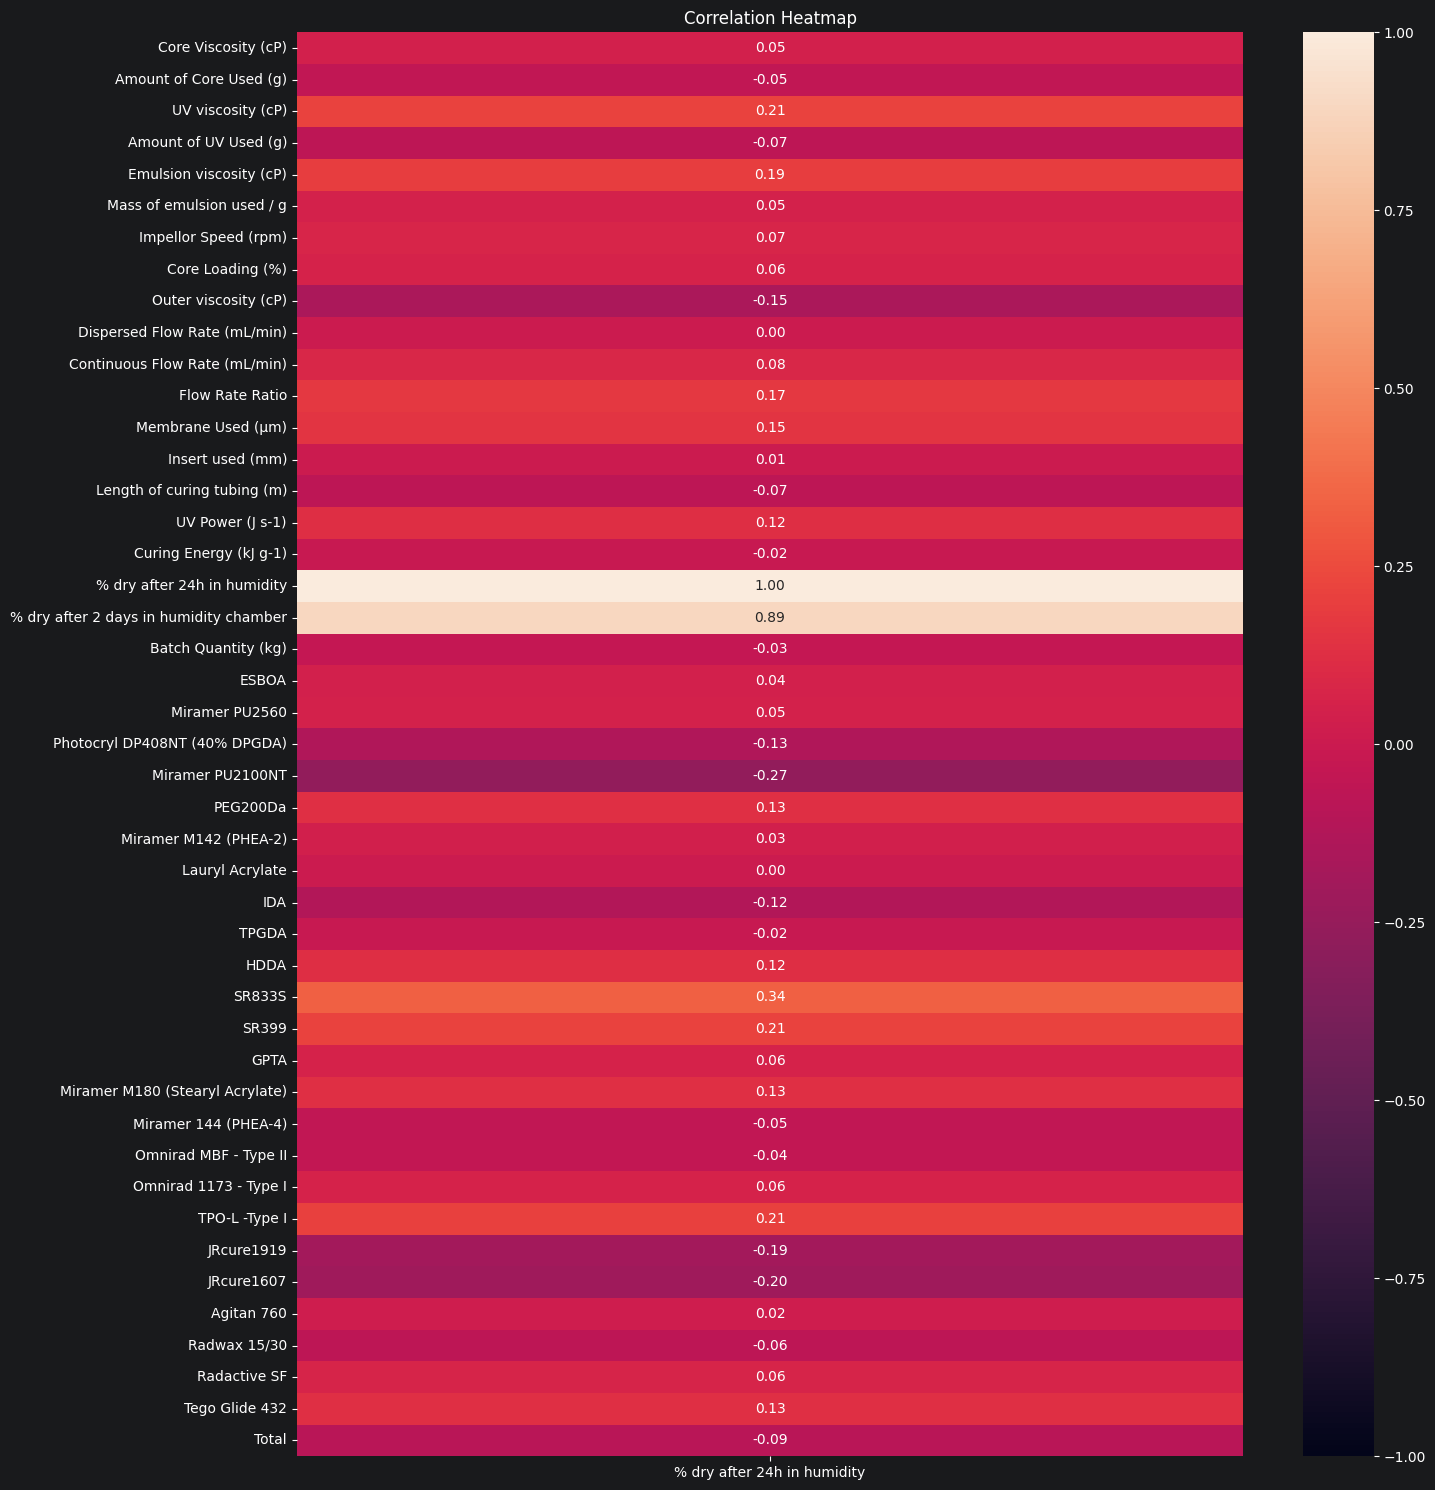

In [14]:
df2c =  df2.select_dtypes(include='number').corr()
cr2 = df2c[['% dry after 24h in humidity']]
cr2 = cr2.dropna()
plt.figure(figsize=(15, 15))
sns.heatmap(cr2.astype(float), annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

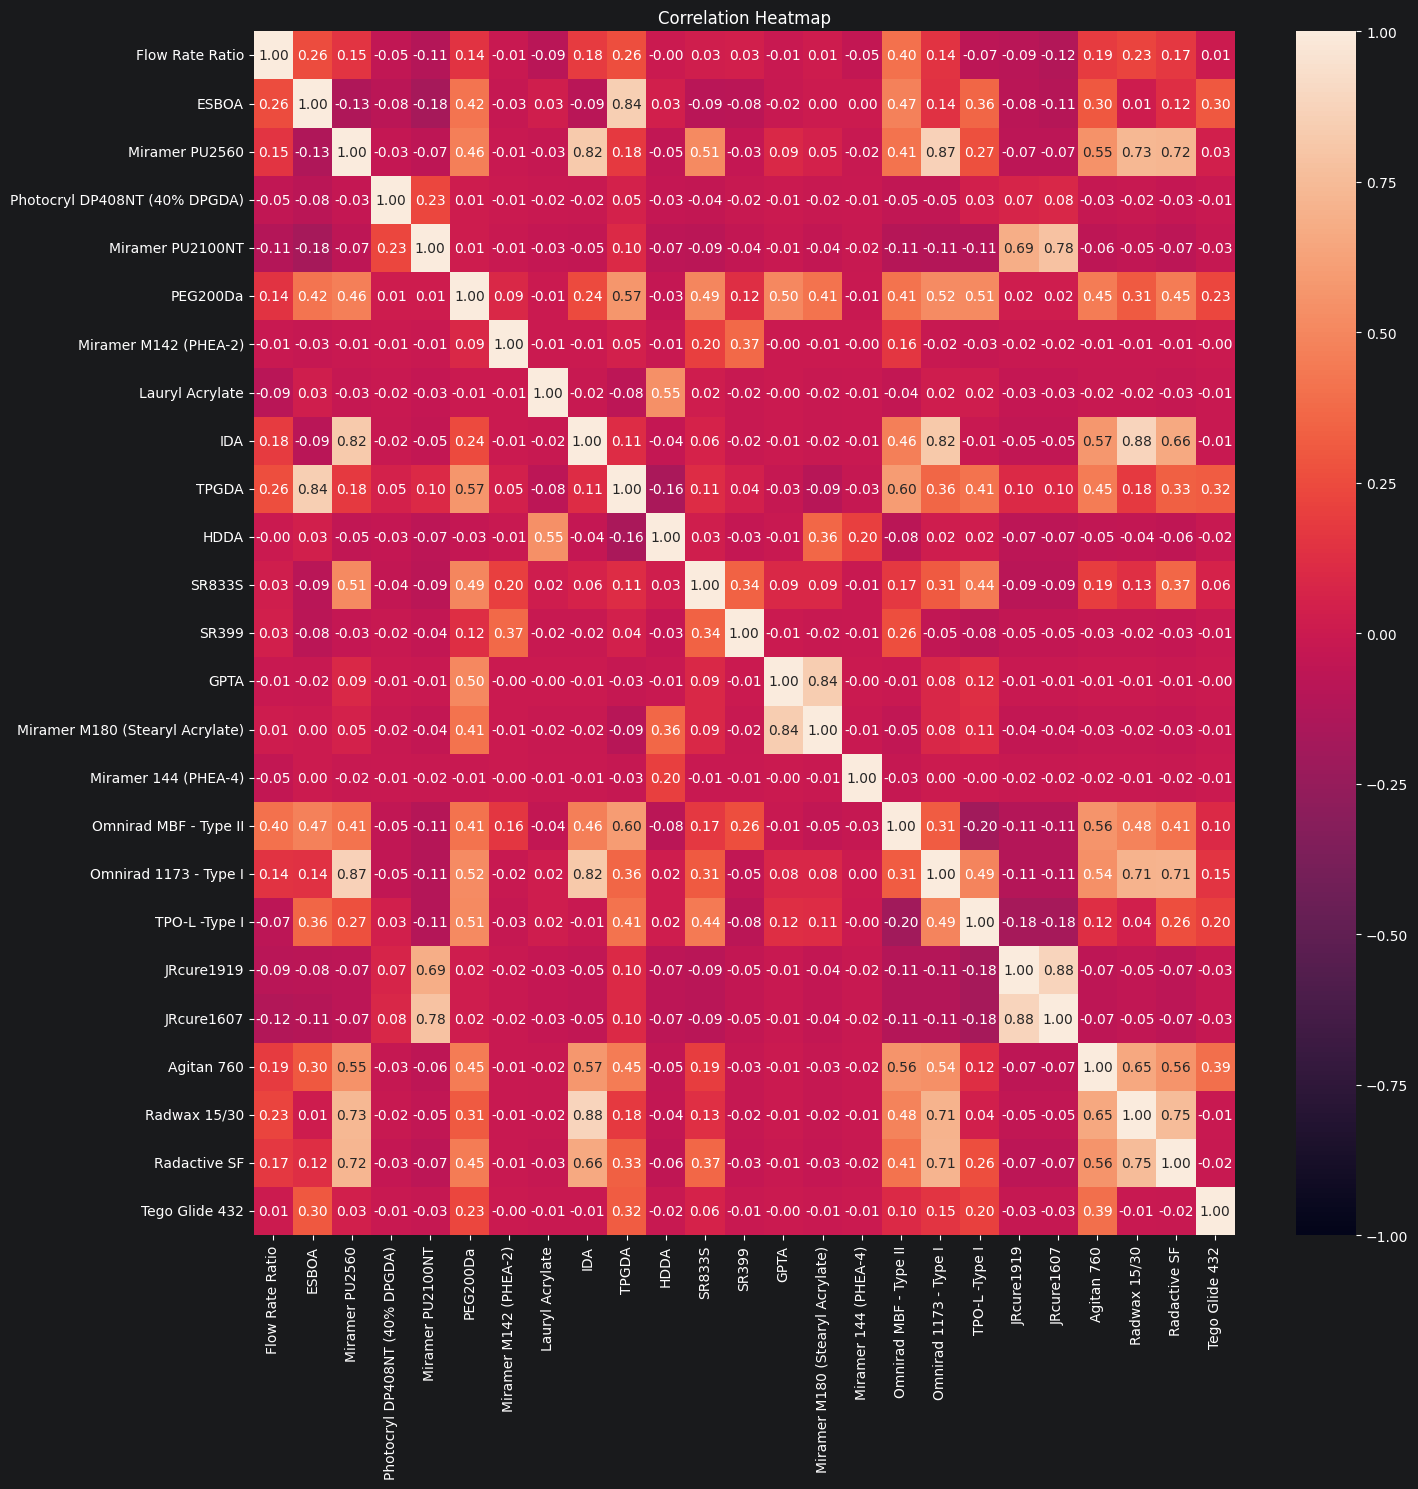

In [15]:
df2c1 =  df2[['Flow Rate Ratio','ESBOA', 'Miramer PU2560',
       'Photocryl DP408NT (40% DPGDA)', 'Miramer PU2100NT', 'PEG200Da', 'Miramer M142 (PHEA-2)',
       'Lauryl Acrylate', 'IDA', 'TPGDA', 'HDDA',
       'SR833S', 'SR399', 'GPTA', 'Miramer M180 (Stearyl Acrylate)', 'Miramer 144 (PHEA-4)', 'Omnirad MBF - Type II', 'Omnirad 1173 - Type I', 'TPO-L -Type I', 'JRcure1919', 'JRcure1607', 'Agitan 760', 'Radwax 15/30', 'Radactive SF', 'Tego Glide 432']].select_dtypes(include='number').corr()

plt.figure(figsize=(15, 15))
sns.heatmap(df2c1.astype(float), annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [16]:
uv_c.columns

Index(['Sample', 'ESBOA', 'Epoxy:GPTA 75:25', 'Miramer PU2560',
       'Photocryl DP408NT (40% DPGDA)', 'Miramer U360NT', 'Miramer U3195NT',
       'Miramer U3926NT', 'Miramer U3969NT', 'Miramer MU9800',
       'Miramer PU2100NT', 'Miramer SIU2400', 'Miramer SIP900',
       'Miramer SP1106', 'BR-5541M', 'BR-640D', 'BR-643', 'BR-990', 'BRC-843D',
       'CN9276', 'PEG200Da', 'PEG360MA', 'Miramer M142 (PHEA-2)',
       'Lauryl Acrylate', 'IDA', 'TPGDA', 'TMP(3EO)TA', 'TMPTA', 'HDDA',
       'SR833S', 'SR399', 'SR834', 'GPTA', 'SR295', 'IBOA', 'IPEMA',
       'Miramer M180 (Stearyl Acrylate)', 'Miramer M166 (NP(EO8)A)',
       'Miramer M2101 (BPA(EO)10DMA', 'Miramer M206 (HD(EO)nDA)',
       'Miramer M4004 (PE(EO)nTA)', 'Sarbio 5201 (DDDA)',
       'Miramer M222 (DPGDA)', 'Miramer 144 (PHEA-4)', 'Debonding Reading',
       'UVF339 (CAB in HDDA)', 'UVF540 (Diamond Solucote in HDDA)',
       'LU62406 (Diamond Receptive in HDDA)', 'LU62407(Diamond CAP in HDDA)',
       'LU62408 (G1159 in HDD

In [17]:
model_9 = smf.ols(
    formula="""
    Q('% dry after 24h in humidity') ~
    Q('Flow Rate Ratio') +
    Q('SR833S') +
    Q('Miramer PU2100NT') +
    Q('SR399') +
    Q('TPO-L -Type I') +
    Q('PEG200Da') +
    Q('IDA') +
    Q('Miramer M180 (Stearyl Acrylate)') +
    Q('Tego Glide 432')
    """,
    data=df2
).fit()

print(model_9.summary())

                                   OLS Regression Results                                   
Dep. Variable:     Q('% dry after 24h in humidity')   R-squared:                       0.275
Model:                                          OLS   Adj. R-squared:                  0.264
Method:                               Least Squares   F-statistic:                     25.63
Date:                              Wed, 29 Apr 2026   Prob (F-statistic):           1.63e-37
Time:                                      16:56:50   Log-Likelihood:                -2894.9
No. Observations:                               619   AIC:                             5810.
Df Residuals:                                   609   BIC:                             5854.
Df Model:                                         9                                         
Covariance Type:                          nonrobust                                         
                                           coef    std err          t 

In [18]:
model_10 = smf.ols(
    formula="""
    Q('% dry after 24h in humidity') ~
    Q('Flow Rate Ratio') +
    Q('SR833S') +
    Q('Miramer PU2100NT') +
    Q('SR399') +
    Q('TPO-L -Type I') +
    Q('IDA') +
    Q('Miramer M180 (Stearyl Acrylate)') +
    Q('Tego Glide 432') +
    Q('TPGDA')
    """,
    data=df2
).fit()

print(model_10.summary())

                                   OLS Regression Results                                   
Dep. Variable:     Q('% dry after 24h in humidity')   R-squared:                       0.271
Model:                                          OLS   Adj. R-squared:                  0.260
Method:                               Least Squares   F-statistic:                     25.12
Date:                              Wed, 29 Apr 2026   Prob (F-statistic):           8.29e-37
Time:                                      16:56:50   Log-Likelihood:                -2896.6
No. Observations:                               619   AIC:                             5813.
Df Residuals:                                   609   BIC:                             5858.
Df Model:                                         9                                         
Covariance Type:                          nonrobust                                         
                                           coef    std err          t 

In [19]:
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor

formula = """
Q('% dry after 24h in humidity') ~
    Q('Flow Rate Ratio') +
    Q('SR833S') +
    Q('Miramer PU2100NT') +
    Q('SR399') +
    Q('TPO-L -Type I') +
    Q('IDA') +
    Q('Miramer M180 (Stearyl Acrylate)') +
    Q('Tego Glide 432') +
    Q('TPGDA')
"""

# Build y and X from the exact regression formula
y, X = dmatrices(formula, data=df2, return_type='dataframe')

# Calculate VIF for each column in X
vif_df = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

# Remove intercept row for easier reading
vif_df = vif_df[vif_df["Variable"] != "Intercept"].reset_index(drop=True)

print(vif_df.sort_values("VIF", ascending=False))

                               Variable       VIF
4                    Q('TPO-L -Type I')  2.247903
8                            Q('TPGDA')  2.049707
1                           Q('SR833S')  1.675579
3                            Q('SR399')  1.354565
7                   Q('Tego Glide 432')  1.198092
0                  Q('Flow Rate Ratio')  1.162480
2                 Q('Miramer PU2100NT')  1.133876
5                              Q('IDA')  1.080468
6  Q('Miramer M180 (Stearyl Acrylate)')  1.049404
